In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import GEOparse

os.chdir(os.path.expanduser('~/projects/lungcell'))
os.makedirs('figures', exist_ok=True)

print("All imports OK")


All imports OK


In [3]:
df = pd.read_csv('data/processed/expression_matrix.csv', index_col=0)

condition = pd.read_csv('data/processed/sample_labels.csv', index_col=0).squeeze()

print(f"Expression matrix shape: {df.shape[0]} genes x {df.shape[1]} samples")
print(f"\nSample counts:")
print(condition.value_counts())
print(f"\nFirst 3 values: {df.iloc[:3, :3]}")


Expression matrix shape: 36742 genes x 169 samples

Sample counts:
condition
cancer    87
normal    77
Name: count, dtype: int64

First 3 values:          accession chrom  start
gene                           
WASH7P   NR_024540     1  14361
FAM138A  NR_026818     1  34610
FAM138F  NR_026820     1  34610


/var/folders/20/0j1g3vmn6k75n7cswz73b47w0000gn/T/ipykernel_65160/1756296211.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/processed/expression_matrix.csv', index_col=0)


In [7]:
expression_cols = df.filter(regex=r'^LC_').columns
log_df = np.log2(df[expression_cols] + 1)  # log-transform expression values only

expressed = log_df.median(axis=1) > 0.5
log_df = log_df[expressed]

print(f"Genes before filtering: {df.shape[0]:,}")
print(f"Genes after filtering: {log_df.shape[0]:,}")
print(f"\nValue range after log transform:")
print(f"  Min: {log_df.min().min():.2f}")
print(f"  Max: {log_df.max().max():.2f}")
print(f"  Mean: {log_df.mean().mean():.2f}")

Genes before filtering: 36,742
Genes after filtering: 26,411

Value range after log transform:
  Min: 0.00
  Max: 14.87
  Mean: 3.31


PC1 explains 19.8% of variation
PC2 explains 10.2% of variation


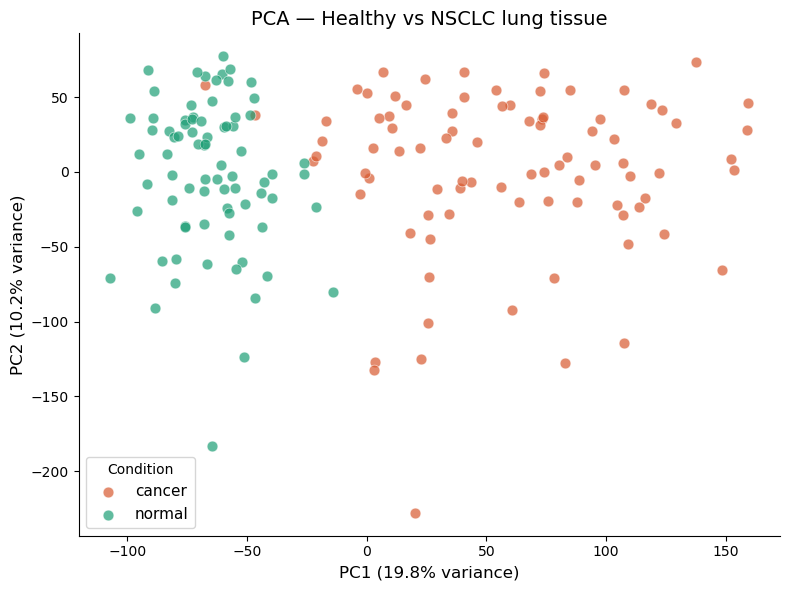

Saved: figures/01_pca.png


In [8]:
X = log_df.T
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

variance_explained = pca.explained_variance_ratio_ * 100
print(f"PC1 explains {variance_explained[0]:.1f}% of variation")
print(f"PC2 explains {variance_explained[1]:.1f}% of variation")

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Condition': condition.values
})

#Plot
fig, ax = plt.subplots(figsize=(8, 6))

colours = {'cancer': "#D85A30", 'normal': "#1D9E75"}

for group, subset in pca_df.groupby('Condition'):
    ax.scatter(subset['PC1'], subset['PC2'], label=group, color=colours[group], alpha=0.7, s= 60, edgecolor='white', linewidth=0.5)
ax.set_xlabel(f'PC1 ({variance_explained[0]:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({variance_explained[1]:.1f}% variance)', fontsize=12)
ax.set_title('PCA — Healthy vs NSCLC lung tissue', fontsize=14)
ax.legend(title='Condition', fontsize=11)
ax.spines['top'].set_visible(False)     # remove top border
ax.spines['right'].set_visible(False)   # remove right border — cleaner look

plt.tight_layout()
plt.savefig('figures/01_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/01_pca.png")

/var/folders/20/0j1g3vmn6k75n7cswz73b47w0000gn/T/ipykernel_66133/4026354296.py:10: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/processed/expression_matrix.csv', index_col=0)


Unique genes after collapsing isoforms: 15,084


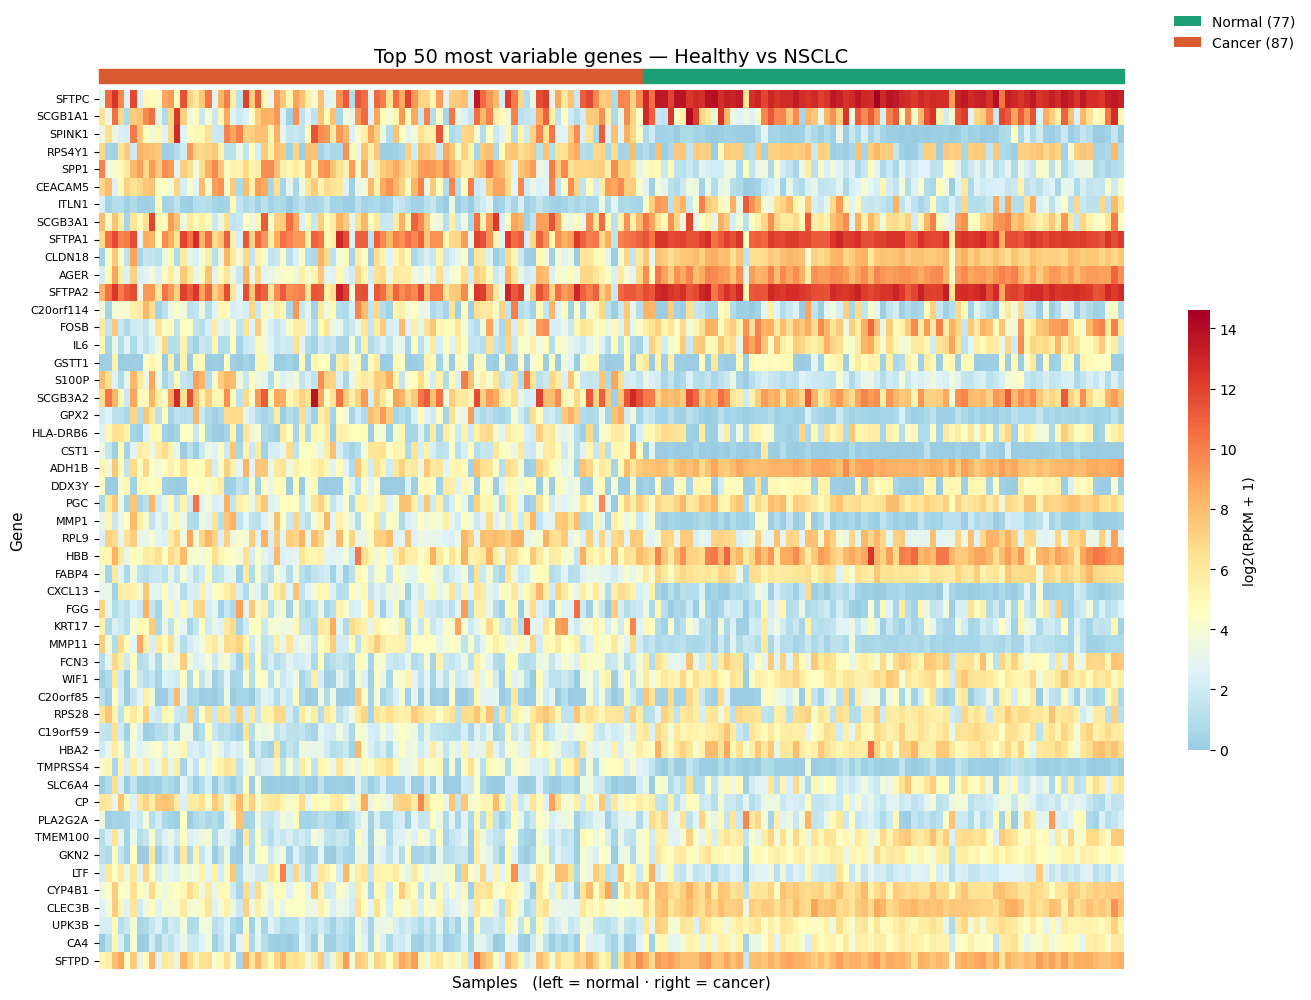

Saved: figures/02_heatmap.png


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

os.chdir(os.path.expanduser('~/projects/lungcell'))

df = pd.read_csv('data/processed/expression_matrix.csv', index_col=0)
condition = pd.read_csv('data/processed/sample_labels.csv', index_col=0).squeeze()

expression_cols = df.filter(regex=r'^LC_').columns
log_df = np.log2(df[expression_cols] + 1)


log_df = log_df[log_df.median(axis=1) > 0.5]


log_df = log_df.groupby(log_df.index).mean()
print(f"Unique genes after collapsing isoforms: {log_df.shape[0]:,}")


top50 = log_df.var(axis=1).nlargest(50).index
heatmap_df = log_df.loc[top50]


sample_order = condition.sort_values().index
heatmap_df = heatmap_df[sample_order]
sorted_condition = condition[sample_order]

center_val = heatmap_df.median().median()


fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    heatmap_df,
    ax=ax,
    cmap='RdYlBu_r',
    center=center_val,
    xticklabels=False,
    yticklabels=True,
    cbar_kws={'label': 'log2(RPKM + 1)', 'shrink': 0.5}
)


colours = {'normal': '#1D9E75', 'cancer': '#D85A30'}
for i, sample in enumerate(sample_order):
    ax.add_patch(plt.Rectangle(
        (i, -1.2), 1, 0.8,
        color=colours[sorted_condition[sample]],
        clip_on=False,
        transform=ax.transData
    ))


legend_elements = [
    mpatches.Patch(facecolor='#1D9E75', label='Normal (77)'),
    mpatches.Patch(facecolor='#D85A30', label='Cancer (87)')
]
ax.legend(
    handles=legend_elements,
    loc='upper right',
    bbox_to_anchor=(1.18, 1.1),
    fontsize=10,
    frameon=False
)

ax.set_title(
    'Top 50 most variable genes — Healthy vs NSCLC',
    fontsize=14, pad=20
)
ax.set_xlabel('Samples   (left = normal · right = cancer)', fontsize=11)
ax.set_ylabel('Gene', fontsize=11)
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('figures/02_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/02_heatmap.png")

/var/folders/20/0j1g3vmn6k75n7cswz73b47w0000gn/T/ipykernel_66133/3123024858.py:10: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/processed/expression_matrix.csv', index_col=0)


Gene counts by direction:
direction
not significant    13834
up in normal         815
up in cancer         435
Name: count, dtype: int64
adjustText not installed — using manual label placement
Install with: pip install adjustText


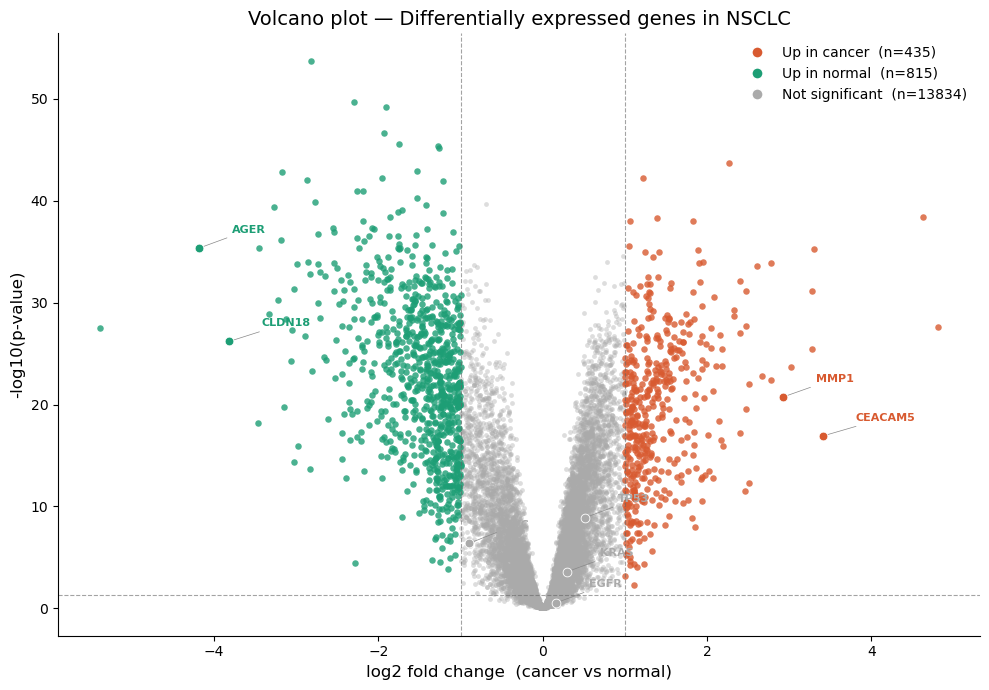

Saved: figures/03_volcano.png


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

os.chdir(os.path.expanduser('~/projects/lungcell'))


df = pd.read_csv('data/processed/expression_matrix.csv', index_col=0)
condition = pd.read_csv('data/processed/sample_labels.csv', index_col=0).squeeze()

expression_cols = df.filter(regex=r'^LC_').columns
log_df = np.log2(df[expression_cols].astype(float) + 1)
log_df = log_df[log_df.median(axis=1) > 0.5]
log_df = log_df.groupby(log_df.index).mean()   # collapse isoforms


cancer_samples = condition[condition == 'cancer'].index
normal_samples  = condition[condition == 'normal'].index


results = []
for gene in log_df.index:
    cancer_vals = log_df.loc[gene, cancer_samples]
    normal_vals  = log_df.loc[gene, normal_samples]

    fold_change = cancer_vals.mean() - normal_vals.mean()
    _, p_value  = stats.ttest_ind(cancer_vals, normal_vals)

    results.append({
        'gene':        gene,
        'fold_change': fold_change,
        'p_value':     p_value
    })

results_df = pd.DataFrame(results)


results_df['-log10_p'] = -np.log10(results_df['p_value'] + 1e-300)

# Label each gene by direction and significance
# Thresholds: p < 0.05  AND  |fold change| > 1 (= 2× change)
sig = (results_df['p_value'] < 0.05) & (results_df['fold_change'].abs() > 1)
results_df['direction'] = 'not significant'
results_df.loc[sig & (results_df['fold_change'] >  1), 'direction'] = 'up in cancer'
results_df.loc[sig & (results_df['fold_change'] < -1), 'direction'] = 'up in normal'

print("Gene counts by direction:")
print(results_df['direction'].value_counts())

# Save for future use
results_df.to_csv('data/processed/differential_expression.csv', index=False)

# ── Plot ──────────────────────────────────────────────────────────────
colour_map = {
    'not significant': '#AAAAAA',
    'up in cancer':    '#D85A30',
    'up in normal':    '#1D9E75'
}
size_map = {
    'not significant': 12,
    'up in cancer':    22,
    'up in normal':    22
}
alpha_map = {
    'not significant': 0.4,
    'up in cancer':    0.8,
    'up in normal':    0.8
}

fig, ax = plt.subplots(figsize=(10, 7))

for direction, subset in results_df.groupby('direction'):
    ax.scatter(
        subset['fold_change'],
        subset['-log10_p'],
        color=colour_map[direction],
        s=size_map[direction],
        alpha=alpha_map[direction],
        label=direction,
        rasterized=True,
        linewidths=0
    )

# Threshold lines
ax.axvline(x= 1, color='#666666', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axvline(x=-1, color='#666666', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(y=-np.log10(0.05), color='#666666',
           linestyle='--', linewidth=0.8, alpha=0.6)

# ── Label specific genes of interest ─────────────────────────────────
# Install if needed: pip install adjustText
try:
    from adjustText import adjust_text

    genes_to_label = [
        'KRAS', 'EGFR', 'TP53', 'MYC', 'ALK',
        'STK11', 'KEAP1', 'CEACAM5', 'MMP1',
        'AGER', 'CLDN18', 'S100P', 'IL6'
    ]

    texts = []
    for gene in genes_to_label:
        row = results_df[results_df['gene'] == gene]
        if len(row) == 0:
            continue
        x = row['fold_change'].values[0]
        y = row['-log10_p'].values[0]
        col = colour_map.get(row['direction'].values[0], '#333333')

        # Highlight dot
        ax.scatter(x, y, s=40, color=col,
                   zorder=5, edgecolors='white', linewidths=0.6)

        texts.append(ax.text(
            x, y, gene,
            fontsize=9, fontweight='bold', color=col
        ))

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle='-', color='#888888', lw=0.5)
    )

except ImportError:
    # Fallback: manual offsets if adjustText not installed
    print("adjustText not installed — using manual label placement")
    print("Install with: pip install adjustText")
    genes_to_label = [
        'KRAS', 'EGFR', 'TP53', 'MYC',
        'CEACAM5', 'MMP1', 'AGER', 'CLDN18'
    ]
    for gene in genes_to_label:
        row = results_df[results_df['gene'] == gene]
        if len(row) == 0:
            continue
        x = row['fold_change'].values[0]
        y = row['-log10_p'].values[0]
        col = colour_map.get(row['direction'].values[0], '#333333')
        ax.scatter(x, y, s=40, color=col,
                   zorder=5, edgecolors='white', linewidths=0.6)
        ax.annotate(
            gene,
            xy=(x, y),
            xytext=(x + 0.4, y + 1.5),
            fontsize=8, fontweight='bold', color=col,
            arrowprops=dict(arrowstyle='-', color='#888888', lw=0.5)
        )

# ── Axes and labels ───────────────────────────────────────────────────
ax.set_xlabel('log2 fold change  (cancer vs normal)', fontsize=12)
ax.set_ylabel('-log10(p-value)', fontsize=12)
ax.set_title('Volcano plot — Differentially expressed genes in NSCLC',
             fontsize=14)

# Clean legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#D85A30', markersize=8,
           label=f"Up in cancer  (n={len(results_df[results_df['direction']=='up in cancer'])})"),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#1D9E75', markersize=8,
           label=f"Up in normal  (n={len(results_df[results_df['direction']=='up in normal'])})"),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#AAAAAA', markersize=8,
           label=f"Not significant  (n={len(results_df[results_df['direction']=='not significant'])})"),
]
ax.legend(handles=legend_elements, fontsize=10, frameon=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/03_volcano.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/03_volcano.png")